<a href="https://colab.research.google.com/github/HONGSAHUN/AI-Class/blob/main/Week04_0928/EX_0928_mpg_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# auto-mpg.data 분류
자동차의 실린더 수, 배기량, 마력, 무게, 가속 성능, 연식, 제조국으로 연비 등급(3등급)을 분류한다.

## 1. 파일 업로드 및 라이브러리

In [1]:
from google.colab import files
files.upload()   # auto-mpg.data

Saving auto-mpg.data to auto-mpg.data


{'auto-mpg.data': b'18.0   8   307.0      130.0      3504.      12.0   70  1\t"chevrolet chevelle malibu"\n15.0   8   350.0      165.0      3693.      11.5   70  1\t"buick skylark 320"\n18.0   8   318.0      150.0      3436.      11.0   70  1\t"plymouth satellite"\n16.0   8   304.0      150.0      3433.      12.0   70  1\t"amc rebel sst"\n17.0   8   302.0      140.0      3449.      10.5   70  1\t"ford torino"\n15.0   8   429.0      198.0      4341.      10.0   70  1\t"ford galaxie 500"\n14.0   8   454.0      220.0      4354.       9.0   70  1\t"chevrolet impala"\n14.0   8   440.0      215.0      4312.       8.5   70  1\t"plymouth fury iii"\n14.0   8   455.0      225.0      4425.      10.0   70  1\t"pontiac catalina"\n15.0   8   390.0      190.0      3850.       8.5   70  1\t"amc ambassador dpl"\n15.0   8   383.0      170.0      3563.      10.0   70  1\t"dodge challenger se"\n14.0   8   340.0      160.0      3609.       8.0   70  1\t"plymouth \'cuda 340"\n15.0   8   400.0      150.0    

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [3]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN":      KNeighborsClassifier(),
    "SVM":      SVC(),
    "Tree":     DecisionTreeClassifier(random_state=42),
    "Forest":   RandomForestClassifier(random_state=42),
}

def compare(models, X_train, X_test, y_train, y_test):
    rows = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rows.append({"model": name,
                     "accuracy": round(accuracy_score(y_test, pred), 3),
                     "macro F1": round(f1_score(y_test, pred, average="macro"), 3)})
    return pd.DataFrame(rows).set_index("model").sort_values("macro F1", ascending=False)

## 2. 데이터 불러오기
공백으로 구분된 파일이며 결측치가 `?`로 표시되어 있다. 차량 이름(`car_name`)은 차량마다 값이 달라 분류에 의미가 없으므로 불러온 직후 제거한다.

In [4]:
df = pd.read_csv("auto-mpg.data", sep=r"\s+", header=None, na_values="?")
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
              'acceleration', 'model_year', 'origin', 'car_name']
df = df.drop('car_name', axis=1)
print(df.shape)
df.head()

(398, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [5]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


## 3. 전처리
- `horsepower` 결측치 6개가 있는 행을 삭제한다.
- `origin`(1=미국, 2=유럽, 3=일본)은 크기가 아닌 범주이므로 원-핫 인코딩한다.

In [6]:
df = df.dropna()
df = pd.get_dummies(df, columns=['origin'], prefix='origin', dtype=int)
print(df.shape)
df.head()

(392, 10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,0,0


## 4. 연비 등급 생성 및 LabelEncoder 적용
`mpg`를 개수가 비슷한 3구간(low, mid, high)으로 나누어 분류 문제로 바꾼다.

In [7]:
df['grade'] = pd.qcut(df['mpg'], q=3, labels=['low', 'mid', 'high']).astype(str)
print(df.groupby('grade')['mpg'].agg(['count', 'min', 'max']))

le = LabelEncoder()
df['grade'] = le.fit_transform(df['grade'])
print(le.classes_)

       count   min   max
grade                   
high     131  27.0  46.6
low      131   9.0  18.6
mid      130  19.0  26.8
['high' 'low' 'mid']


## 5. 데이터 분할 및 스케일링
등급을 `mpg`로 만들었으므로 `mpg`는 입력에서 제외한다. 스케일러는 훈련 데이터로만 학습시킨다.

In [8]:
X = df.drop(['mpg', 'grade'], axis=1).values
y = df['grade'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(X_train_s.shape, X_test_s.shape)

(313, 9) (79, 9)


## 6. 모델 비교

In [9]:
result_mpg = compare(models, X_train_s, X_test_s, y_train, y_test)
result_mpg

,accuracy,macro F1
model,,
Tree,0.899,0.898
SVM,0.848,0.846
KNN,0.835,0.835
Logistic,0.823,0.821
Forest,0.810,0.806


최고 모델: Tree
              precision    recall  f1-score   support

        high       0.96      0.89      0.92        27
         low       0.89      0.96      0.93        26
         mid       0.85      0.85      0.85        26

    accuracy                           0.90        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.90      0.90      0.90        79



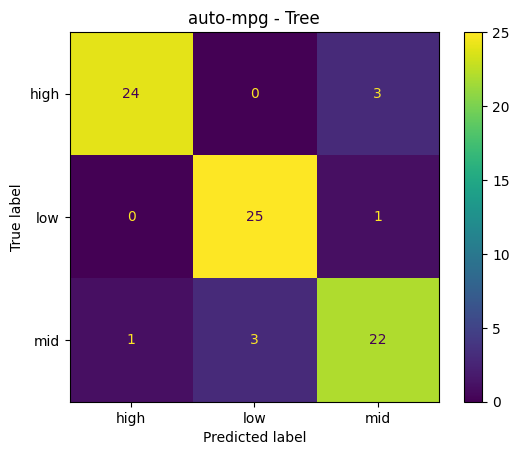

In [10]:
best_name = result_mpg.index[0]
pred = models[best_name].predict(X_test_s)
print("최고 모델:", best_name)
print(classification_report(y_test, pred, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=le.classes_)
plt.title("auto-mpg - " + best_name); plt.show()

---
# 결과 정리
- 결정 트리의 성능이 가장 높았다(macro F1 0.898).
- 오분류는 모두 `mid`와 인접 등급 사이에서 발생했고, `high`와 `low`를 혼동한 경우는 없었다.
- 시험 데이터가 79개로 적어 분할 방식에 따라 모델 순위가 달라질 수 있다.